<a href="https://colab.research.google.com/github/SharanyaKUMAR22/Tomato-Disease-Detection/blob/main/AUC%2CROC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
import numpy as np
import gc

MODEL_PATH = "/content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded!")
print("GPU:", tf.config.list_physical_devices("GPU"))

Model loaded!
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
DATA_DIR = "/content/data"

dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(224, 224),
    batch_size=8,
    shuffle=False,
    label_mode="categorical"
)

class_names = dataset.class_names

print("Dataset loaded!")
print("Images: 16011")
print("Classes:", class_names)

Found 16011 files belonging to 10 classes.
Dataset loaded!
Images: 16011
Classes: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [4]:
y_true = []
y_prob = []

print("Starting prediction...")

for batch_no, (images, labels) in enumerate(dataset):

    probabilities = model(images, training=False).numpy()

    y_prob.append(probabilities)
    y_true.append(labels.numpy())

    if (batch_no + 1) % 100 == 0:
        print(f"Processed {batch_no + 1} batches")

y_prob = np.concatenate(y_prob)
y_true = np.concatenate(y_true)

y_true = np.argmax(y_true, axis=1)
y_pred = np.argmax(y_prob, axis=1)

print("\n✅ PREDICTION COMPLETE!")
print("Images:", len(y_true))
print("Prediction shape:", y_prob.shape)

Starting prediction...
Processed 100 batches
Processed 200 batches
Processed 300 batches
Processed 400 batches
Processed 500 batches
Processed 600 batches
Processed 700 batches
Processed 800 batches
Processed 900 batches
Processed 1000 batches
Processed 1100 batches
Processed 1200 batches
Processed 1300 batches
Processed 1400 batches
Processed 1500 batches
Processed 1600 batches
Processed 1700 batches
Processed 1800 batches
Processed 1900 batches
Processed 2000 batches

✅ PREDICTION COMPLETE!
Images: 16011
Prediction shape: (16011, 10)


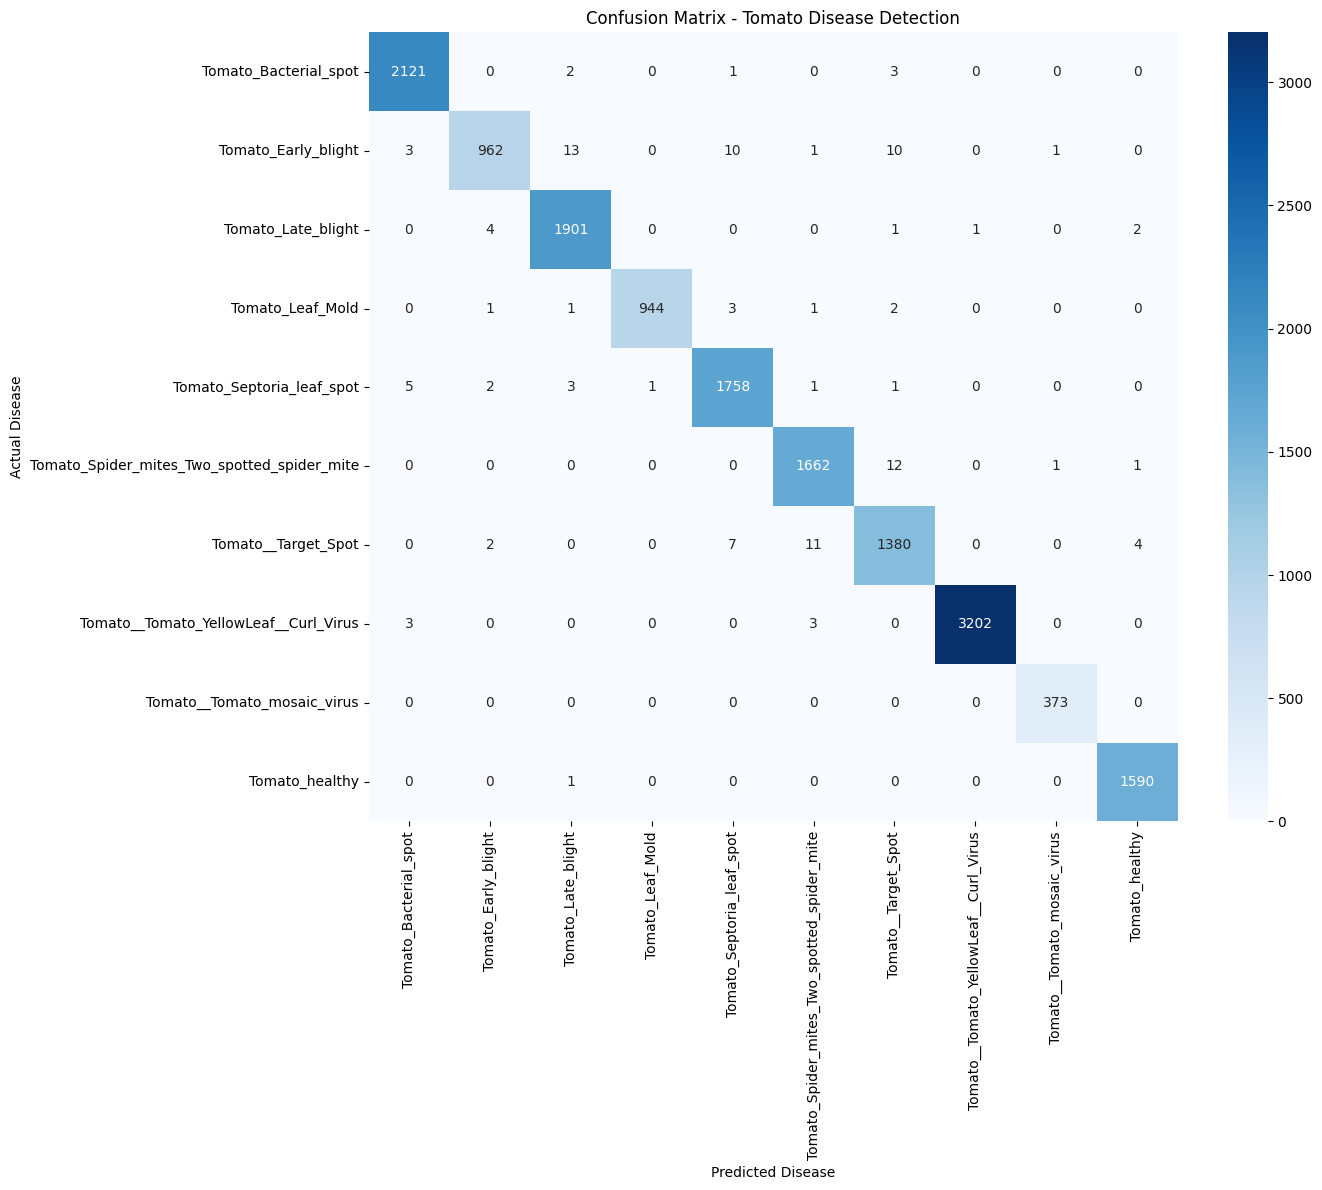

In [5]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("Confusion Matrix - Tomato Disease Detection")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Convert actual labels to one-vs-rest format
y_true_binary = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

# Overall Macro AUC
macro_auc = roc_auc_score(
    y_true_binary,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print("======================================")
print("OVERALL AUC SCORE")
print("======================================")

print(f"Macro AUC: {macro_auc:.4f}")

OVERALL AUC SCORE
Macro AUC: 0.9999


In [7]:
print("======================================")
print("AUC FOR EACH DISEASE")
print("======================================")

for i, disease in enumerate(class_names):

    disease_auc = roc_auc_score(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    print(f"{disease}: {disease_auc:.4f}")

AUC FOR EACH DISEASE
Tomato_Bacterial_spot: 1.0000
Tomato_Early_blight: 0.9995
Tomato_Late_blight: 0.9999
Tomato_Leaf_Mold: 1.0000
Tomato_Septoria_leaf_spot: 1.0000
Tomato_Spider_mites_Two_spotted_spider_mite: 0.9999
Tomato__Target_Spot: 0.9995
Tomato__Tomato_YellowLeaf__Curl_Virus: 1.0000
Tomato__Tomato_mosaic_virus: 1.0000
Tomato_healthy: 1.0000


In [8]:
print("Model evaluation images:", len(y_true))
print("Unique actual classes:", np.unique(y_true))

Model evaluation images: 16011
Unique actual classes: [0 1 2 3 4 5 6 7 8 9]


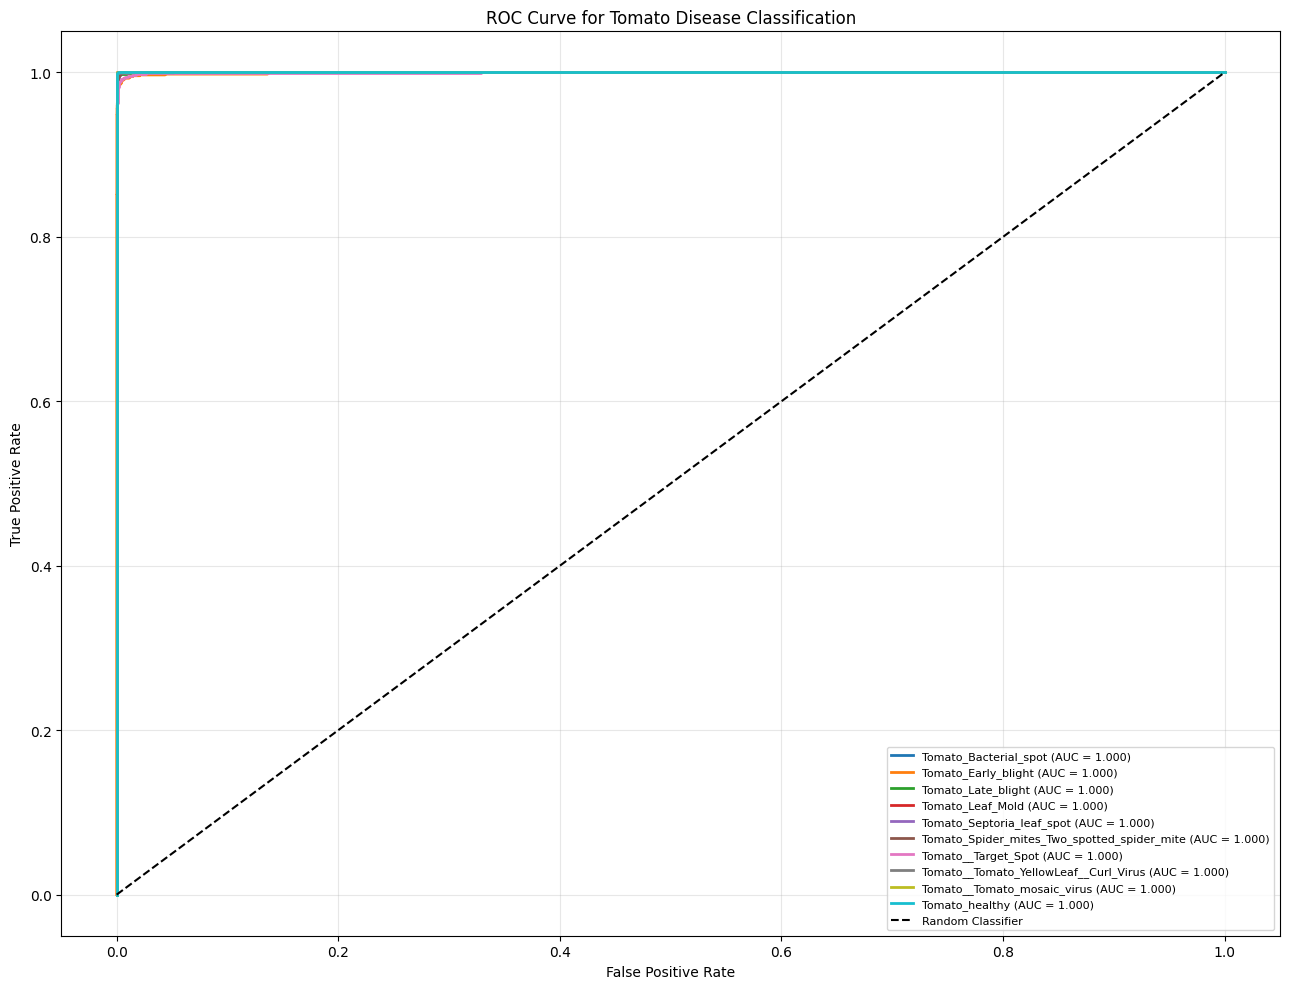

In [9]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(13, 10))

for i, disease in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    disease_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{disease} (AUC = {disease_auc:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve for Tomato Disease Classification"
)

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
plt.savefig(
    "/content/drive/MyDrive/Tomato_Disease_Project/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [11]:
plt.savefig(
    "/content/drive/MyDrive/Tomato_Disease_Project/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [12]:
macro_auc = roc_auc_score(
    y_true_binary,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print(f"Macro AUC: {macro_auc:.4f}")

Macro AUC: 0.9999


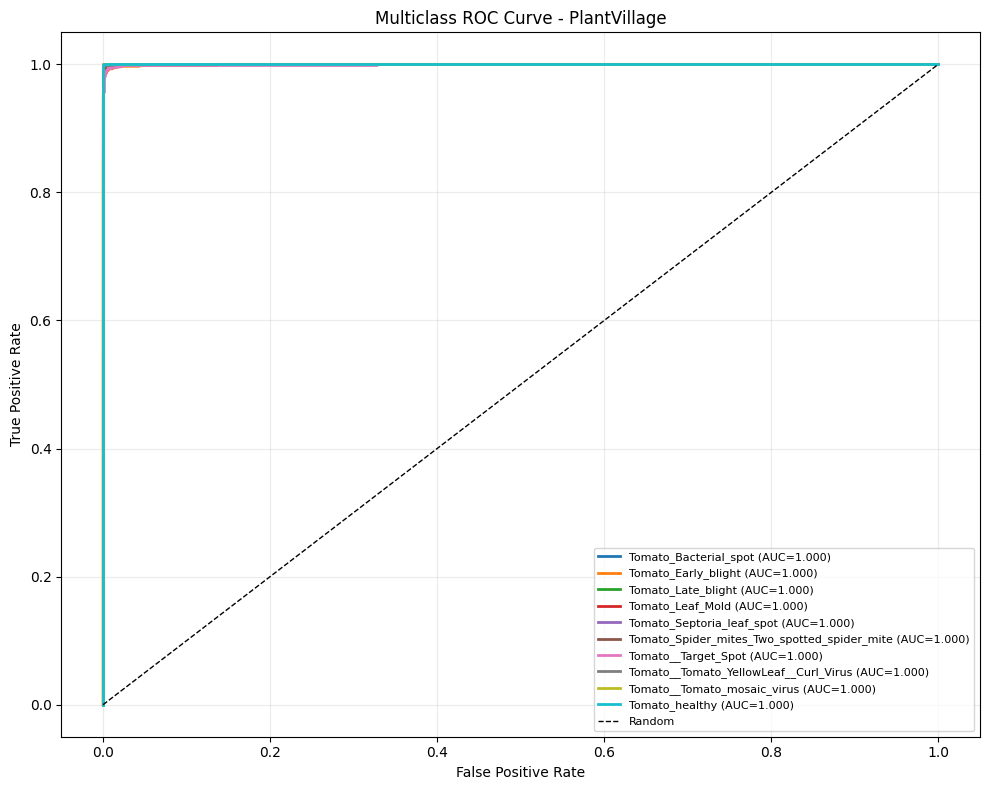

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for i, disease in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    disease_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{disease} (AUC={disease_auc:.3f})"
    )

plt.plot(
    [0, 1], [0, 1],
    "k--",
    linewidth=1,
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - PlantVillage")

plt.legend(fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Tomato_Disease_Project/ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

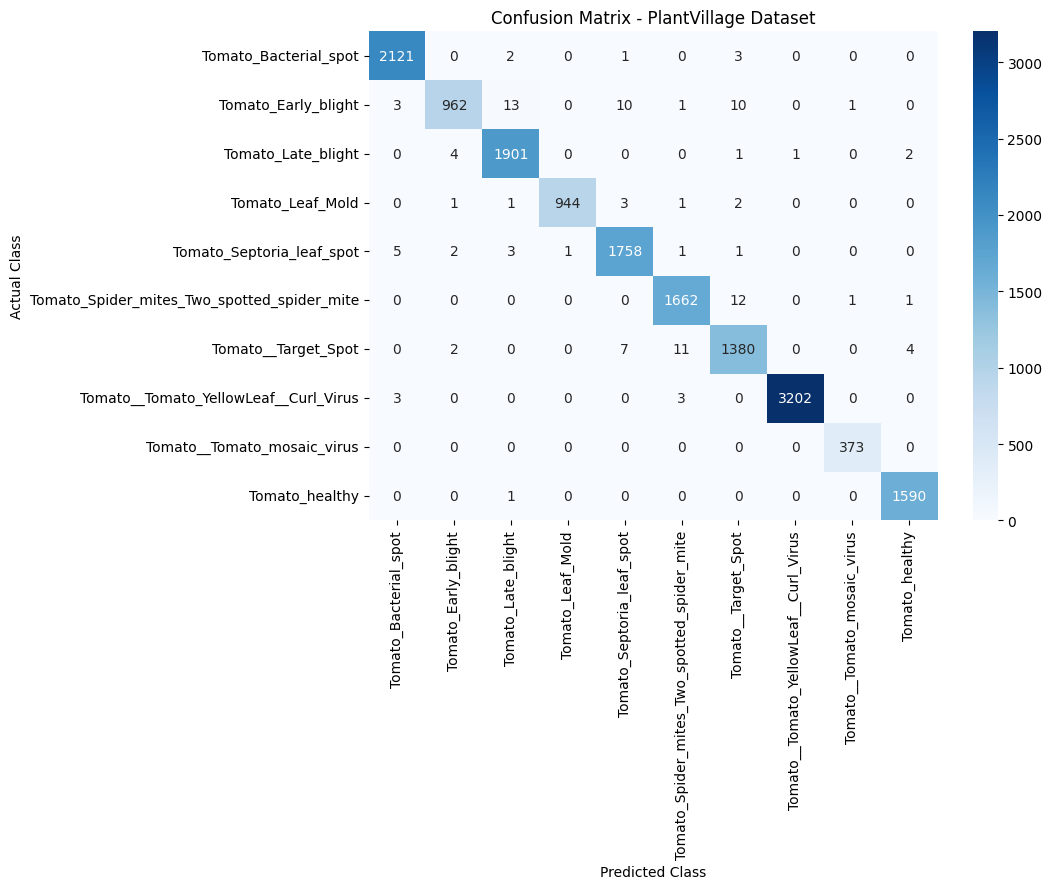

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - PlantVillage Dataset")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Tomato_Disease_Project/Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()